# Image-quality metrics vs neuron-subset ablation, 20 random test stimuli

Evaluates **full-image sequential** reconstructions on 20 randomly sampled test stimuli across neuron-ablation levels using the category-conditioned multihead models (`hvm_cat` for global SigLIP, `hvm_obj_cat` for obj SigLIP).

For each `n_neurons` in `{100, 500, 1000, 2000, full}`, we run 5 seeds and average the per-stimulus metrics. The full model is also run fresh here (same seed convention as the ablated models) so the comparison is apples-to-apples.

**Metrics** (all against the GT reference full image):
- SSIM (↑), PixCorr (↑), LPIPS (↓), SigLIP-cos (↑), 2-AFC (↑)

In [1]:
import re, sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import (
    SEED, HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, HVM_SIGLIP_EMBEDDINGS_PATH,
    HVM_CLIP_EMBEDS_PATH, SIGLIP_DIM,
    HVM_CATEGORIES, HVM_N_VAR, HVM_N_CAT, HVM_N_STIMULI,
    HVM_IMG_SIZE, HVM_STRIP_LABEL_H,
    FLUX_LORA_DEFAULT_PATH, HVM_STIM_DIR,
)
from data_utils.hvm_loader import _category_stratified_split, _load_hvm_neural
from encoders import MultiHeadTransformer
from encoders.siglip_embed import load_siglip, embed_images_stripped
from eval.metrics import ssim, lpips_distance, pixcorr, two_afc_identification
from generation.flux_instantx import load_pipeline, generate_obj_sequential, encode_text_embeds
from generation.aperture import load_hvm_packed_aperture_mask
from generation.project_hvm import load_hvm_bboxes
from get_device import get_device

DEVICE = get_device()

# ── 20 random test stimuli (deterministic) ────────────────────────────────────
_, _, test_idx_all = _category_stratified_split(SEED)
test_idx_all = [int(i) for i in test_idx_all]
rng = np.random.default_rng(SEED)
chosen = sorted(rng.choice(len(test_idx_all), size=20, replace=False).tolist())
test_idx = [test_idx_all[i] for i in chosen]
N = len(test_idx)
print(f'Selected {N} test stimuli: {test_idx}')

# ── ablation config ───────────────────────────────────────────────────────────
NN_VALS  = [100, 500, 1000, 2000]   # neuron-subset sizes to ablate
N_SEEDS  = 5                         # seeds per level
FULL_KEY = 'full'                    # label for the no-ablation ceiling

# ── shared generation constants ───────────────────────────────────────────────
STRENGTH        = 0.65
OBJ_STRENGTH    = 0.75
IP_SCALE        = 1.0
BBOX_PRESERVE   = 0.55
BBOX_TRANSITION = 10
NUM_STEPS       = 20
IMAGE_SIZE      = HVM_IMG_SIZE
BBOX_SRC        = 276
LABEL_H         = HVM_STRIP_LABEL_H

to_tensor = T.ToTensor()

try:
    _font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 14)
except Exception:
    _font = ImageFont.load_default()

Selected 20 test stimuli: [5, 18, 64, 89, 155, 189, 224, 182, 235, 284, 275, 270, 290, 357, 328, 343, 392, 376, 379, 416]


In [2]:
# ── GT data ───────────────────────────────────────────────────────────────────
siglip_gt     = torch.load(HVM_SIGLIP_EMBEDDINGS_PATH,     weights_only=True)  # (450, 1152)
siglip_obj_gt = torch.load(HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, weights_only=True)  # (450, 1152)
clip_gt       = torch.load(HVM_CLIP_EMBEDS_PATH,            weights_only=True)  # (450, 768)
bboxes        = load_hvm_bboxes()

full_sig_gt   = siglip_gt[test_idx]                        # (N, 1152)
full_sig_gt_n = F.normalize(full_sig_gt, dim=-1)

# ── neural responses ──────────────────────────────────────────────────────────
rsp, _, _ = _load_hvm_neural()
_, n_neurons_total, _ = rsp.shape
print(f'Total neurons: {n_neurons_total}')

neural_tensor = torch.from_numpy(rsp).float()              # (450, N_neurons, T)
cat_indices   = torch.arange(HVM_N_STIMULI) // HVM_N_VAR  # (450,)

# ── full-model checkpoint paths (from best_hvm_multihead_config.json) ─────────
import json as _json
_cfg_g   = _json.loads(Path('cache/best_hvm_multihead_config.json').read_text())
_cfg_obj = _json.loads(Path('cache/best_hvm_multihead_obj_config.json').read_text())
FULL_CKPT_GLOBAL = Path(_cfg_g['checkpoint'])
FULL_CKPT_OBJ    = Path(_cfg_obj['checkpoint'])

# ── locate ablation checkpoints ───────────────────────────────────────────────
NN_RE = re.compile(r'_nn(\d+)_ns(\d+)')

def find_ablation_ckpt(subdir, n_neurons, seed):
    base = Path('checkpoints/multihead') / subdir
    for d in base.iterdir():
        if not d.is_dir(): continue
        m = NN_RE.search(d.name)
        if m and int(m.group(1)) == n_neurons and int(m.group(2)) == seed:
            best = d / 'best.pt'
            if best.exists():
                return best
    raise FileNotFoundError(f'{subdir} nn={n_neurons} seed={seed}')

# quick sanity check
for nn in NN_VALS:
    for ns in range(N_SEEDS):
        find_ablation_ckpt('hvm_cat',     nn, ns)
        find_ablation_ckpt('hvm_obj_cat', nn, ns)
print('All checkpoint paths verified.')
print(f'Full model global: {FULL_CKPT_GLOBAL.name}')
print(f'Full model obj:    {FULL_CKPT_OBJ.name}')

Loading HVM sessions: 100%|██████████| 10/10 [00:41<00:00,  4.17s/it]


Total neurons: 2330
All checkpoint paths verified.
Full model global: best.pt
Full model obj:    best.pt


In [3]:
def load_model_from_ckpt(ckpt_path):
    """Load a MultiHeadTransformer from a checkpoint, respecting neuron_indices."""
    ckpt = torch.load(ckpt_path, weights_only=False, map_location='cpu')
    args = ckpt['args']
    ni   = ckpt.get('neuron_indices')        # None for full model
    n_in = len(ni) if ni is not None else n_neurons_total
    m = MultiHeadTransformer(
        n_neurons=n_in,
        d_model=int(args['d_model']), n_heads=int(args['n_heads']),
        n_layers=int(args['n_layers']), shared_dim=int(args['shared_dim']),
        dropout=float(args['dropout']), n_categories=HVM_N_CAT,
    )
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m, ni


def predict_embeddings(model, neural_tensor, cat_indices, neuron_indices=None):
    """Run model on all 450 stimuli; slice neuron_indices if given."""
    sigs, clips = [], []
    with torch.no_grad():
        for i in range(HVM_N_STIMULI):
            x = neural_tensor[i:i+1]                         # (1, N_total, T)
            if neuron_indices is not None:
                x = x[:, neuron_indices, :]                   # (1, n_sub, T)
            x   = x.permute(0, 2, 1)                         # (1, T, n_sub)
            cat = cat_indices[i:i+1]
            out = model(x, cat)
            sigs.append(out['siglip'].cpu())
            clips.append(out['clip'].cpu())
    return torch.cat(sigs), torch.cat(clips)                  # (450, D)


def load_stimulus(global_idx):
    cat = HVM_CATEGORIES[global_idx // HVM_N_VAR]
    var = global_idx % HVM_N_VAR
    return Image.open(HVM_STIM_DIR / cat / f'{var:02d}.png').convert('RGB').resize(
        (IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)

print('Helpers defined.')

Helpers defined.


In [4]:
# ── load FLUX pipeline (shared across all ablation levels) ────────────────────
pipe, image_proj = load_pipeline(device=DEVICE, default_scale=1.0, flux_lora_path=FLUX_LORA_DEFAULT_PATH)
hvm_aperture     = load_hvm_packed_aperture_mask(image_size=IMAGE_SIZE, device='cpu', dtype=torch.bfloat16)
cat_clip_embeds, cat_t5_embeds = encode_text_embeds(pipe, list(HVM_CATEGORIES))
_, null_t5   = encode_text_embeds(pipe, [''])
zero_siglip  = torch.zeros(SIGLIP_DIM)

seq_shared = dict(
    strength=STRENGTH, obj_strength=OBJ_STRENGTH,
    num_inference_steps=NUM_STEPS, guidance_scale=3.5,
    bbox_preserve_start=BBOX_PRESERVE, image_size=IMAGE_SIZE,
    bbox_src=BBOX_SRC, bbox_transition=BBOX_TRANSITION,
    aperture_mask=hvm_aperture, show_progress=False,
    prompt_embeds=null_t5,
)

print('FLUX pipeline loaded.')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


FLUX pipeline loaded.


In [6]:
# ── generate strips for each (n_neurons, seed) and save to disk ───────────────
# Each strip: Original | Neural pred  (2 cols, same seed convention for all levels)
# Full model runs with the same 5 seeds so it's directly comparable.

def add_label_strip(images, labels, label_h=LABEL_H):
    w, h = images[0].size
    canvas = Image.new('RGB', (w * len(images), h + label_h), color=(30, 30, 30))
    draw = ImageDraw.Draw(canvas)
    for j, (img, lbl) in enumerate(zip(images, labels)):
        canvas.paste(img, (w * j, label_h))
        bbox = draw.textbbox((0, 0), lbl, font=_font)
        tw = bbox[2] - bbox[0]
        draw.text((w * j + (w - tw) // 2, 2), lbl, font=_font, fill=(255, 255, 255))
    return canvas


def run_generation(ckpt_global, ckpt_obj, out_dir, label, neuron_indices_g=None, neuron_indices_obj=None):
    """Load models, predict embeddings, generate and save strips for all test_idx."""
    model_g,   _ = load_model_from_ckpt(ckpt_global)
    model_obj, _ = load_model_from_ckpt(ckpt_obj)

    sig_global, _         = predict_embeddings(model_g,   neural_tensor, cat_indices, neuron_indices_g)
    sig_obj,    pred_clip = predict_embeddings(model_obj, neural_tensor, cat_indices, neuron_indices_obj)
    del model_g, model_obj

    out_dir.mkdir(parents=True, exist_ok=True)
    for i, stim_idx in enumerate(tqdm(test_idx, desc=label, leave=False)):
        orig  = load_stimulus(stim_idx)
        bbox  = bboxes[stim_idx]

        recon = generate_obj_sequential(
            pipe, image_proj, orig, bbox,
            obj_siglip=sig_obj[stim_idx],
            global_siglip=sig_global[stim_idx],
            obj_ip_scale=IP_SCALE, global_ip_scale=IP_SCALE,
            pooled_prompt_embeds=pred_clip[stim_idx].unsqueeze(0),
            seed=i, **seq_shared)

        add_label_strip([orig, recon], ['Original', label]).save(
            out_dir / f'stim{stim_idx:04d}.png')


# ablated levels
for nn in NN_VALS:
    for seed in range(N_SEEDS):
        out_dir = Path(f'outputs/ablation/nn{nn}_ns{seed}')
        if out_dir.exists() and len(list(out_dir.glob('stim*.png'))) == N:
            print(f'nn={nn} seed={seed}: already exists, skipping')
            continue
        ckpt_g   = find_ablation_ckpt('hvm_cat',     nn, seed)
        ckpt_obj = find_ablation_ckpt('hvm_obj_cat', nn, seed)
        ckpt_data_g   = torch.load(ckpt_g,   weights_only=False, map_location='cpu')
        ckpt_data_obj = torch.load(ckpt_obj, weights_only=False, map_location='cpu')
        run_generation(ckpt_g, ckpt_obj, out_dir, f'nn={nn} s{seed}',
                       neuron_indices_g=ckpt_data_g.get('neuron_indices'),
                       neuron_indices_obj=ckpt_data_obj.get('neuron_indices'))
        print(f'nn={nn} seed={seed}: saved {N} strips')

# full model — run once per seed with the same seed index for fair comparison
for seed in range(N_SEEDS):
    out_dir = Path(f'outputs/ablation/full_ns{seed}')
    if out_dir.exists() and len(list(out_dir.glob('stim*.png'))) == N:
        print(f'full seed={seed}: already exists, skipping')
        continue
    run_generation(FULL_CKPT_GLOBAL, FULL_CKPT_OBJ, out_dir, f'full s{seed}')
    print(f'full seed={seed}: saved {N} strips')

print('\nAll strips generated.')


nn=100 seed=0: already exists, skipping
nn=100 seed=1: already exists, skipping
nn=100 seed=2: already exists, skipping
nn=100 seed=3: already exists, skipping
nn=100 seed=4: already exists, skipping
nn=500 seed=0: already exists, skipping
nn=500 seed=1: already exists, skipping
nn=500 seed=2: already exists, skipping
nn=500 seed=3: already exists, skipping
nn=500 seed=4: already exists, skipping
nn=2000 seed=0: already exists, skipping
nn=2000 seed=1: already exists, skipping
nn=2000 seed=2: already exists, skipping
nn=2000 seed=3: already exists, skipping
nn=2000 seed=4: already exists, skipping


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


full s0:   0%|          | 0/20 [00:00<?, ?it/s]

full seed=0: saved 20 strips


full s1:   0%|          | 0/20 [00:00<?, ?it/s]

...

full seed=2: saved 20 strips


full s3:   0%|          | 0/20 [00:00<?, ?it/s]

full seed=3: saved 20 strips


full s4:   0%|          | 0/20 [00:00<?, ?it/s]

full seed=4: saved 20 strips

All strips generated.


In [7]:
# ── load originals (same for all levels) ─────────────────────────────────────
full_originals = []
for stim_idx in test_idx:
    strip = Image.open(Path('outputs/ablation/full_ns0') / f'stim{stim_idx:04d}.png').convert('RGB')
    full_originals.append(strip.crop((0, LABEL_H, IMAGE_SIZE, LABEL_H + IMAGE_SIZE)))

full_orig_t = torch.stack([to_tensor(o) for o in full_originals])  # (N, 3, H, W)
print(f'Loaded {N} reference originals.')


Loaded 20 reference originals.


In [8]:
# ── SigLIP embed all recons in one pass ──────────────────────────────────────
# Order: [nn=100 s0..4, nn=500 s0..4, nn=1000 s0..4, nn=2000 s0..4, full s0..4]
siglip_proc, siglip_model = load_siglip(device=DEVICE)

all_recon_imgs = []
ablation_order = []  # (nn_key, seed)

for nn in NN_VALS:
    for seed in range(N_SEEDS):
        out_dir = Path(f'outputs/ablation/nn{nn}_ns{seed}')
        imgs = [Image.open(out_dir / f'stim{stim_idx:04d}.png').convert('RGB')
                .crop((IMAGE_SIZE, LABEL_H, 2 * IMAGE_SIZE, LABEL_H + IMAGE_SIZE))
                for stim_idx in test_idx]
        all_recon_imgs.extend(imgs)
        ablation_order.append((nn, seed))

for seed in range(N_SEEDS):
    out_dir = Path(f'outputs/ablation/full_ns{seed}')
    imgs = [Image.open(out_dir / f'stim{stim_idx:04d}.png').convert('RGB')
            .crop((IMAGE_SIZE, LABEL_H, 2 * IMAGE_SIZE, LABEL_H + IMAGE_SIZE))
            for stim_idx in test_idx]
    all_recon_imgs.extend(imgs)
    ablation_order.append((FULL_KEY, seed))

all_sigs = embed_images_stripped(siglip_proc, siglip_model, all_recon_imgs)

recon_sigs = {}
for block_i, key in enumerate(ablation_order):
    recon_sigs[key] = all_sigs[block_i * N : (block_i + 1) * N]

del siglip_proc, siglip_model, all_recon_imgs, all_sigs
torch.cuda.empty_cache()
print(f'Embedded {len(ablation_order)} blocks x {N} images.')


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Embedded 20 blocks × 20 images.


In [9]:
# ── compute per-(nn, seed) metrics ────────────────────────────────────────────
import lpips as lpips_lib
_lpips_fn = lpips_lib.LPIPS(net='vgg').cpu()

def compute_metrics(imgs, rec_sigs, orig_t, sig_gt, sig_gt_norm, batch_size=8):
    rec_t = torch.stack([to_tensor(r) for r in imgs])
    return dict(
        ssim=ssim(rec_t, orig_t),
        lpips=lpips_distance(rec_t, orig_t, batch_size=batch_size, lpips_fn=_lpips_fn),
        pixcorr=pixcorr(rec_t, orig_t),
        siglip_cos=F.cosine_similarity(rec_sigs, sig_gt_norm, dim=-1).numpy(),
        afc_2=two_afc_identification(rec_sigs, sig_gt),
    )


all_metrics = {}

for nn in NN_VALS:
    for seed in range(N_SEEDS):
        key = (nn, seed)
        out_dir = Path(f'outputs/ablation/nn{nn}_ns{seed}')
        imgs = [Image.open(out_dir / f'stim{stim_idx:04d}.png').convert('RGB')
                .crop((IMAGE_SIZE, LABEL_H, 2 * IMAGE_SIZE, LABEL_H + IMAGE_SIZE))
                for stim_idx in test_idx]
        all_metrics[key] = compute_metrics(imgs, recon_sigs[key], full_orig_t, full_sig_gt, full_sig_gt_n)

for seed in range(N_SEEDS):
    key = (FULL_KEY, seed)
    out_dir = Path(f'outputs/ablation/full_ns{seed}')
    imgs = [Image.open(out_dir / f'stim{stim_idx:04d}.png').convert('RGB')
            .crop((IMAGE_SIZE, LABEL_H, 2 * IMAGE_SIZE, LABEL_H + IMAGE_SIZE))
            for stim_idx in test_idx]
    all_metrics[key] = compute_metrics(imgs, recon_sigs[key], full_orig_t, full_sig_gt, full_sig_gt_n)

print('Metrics computed for all levels and seeds.')


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/

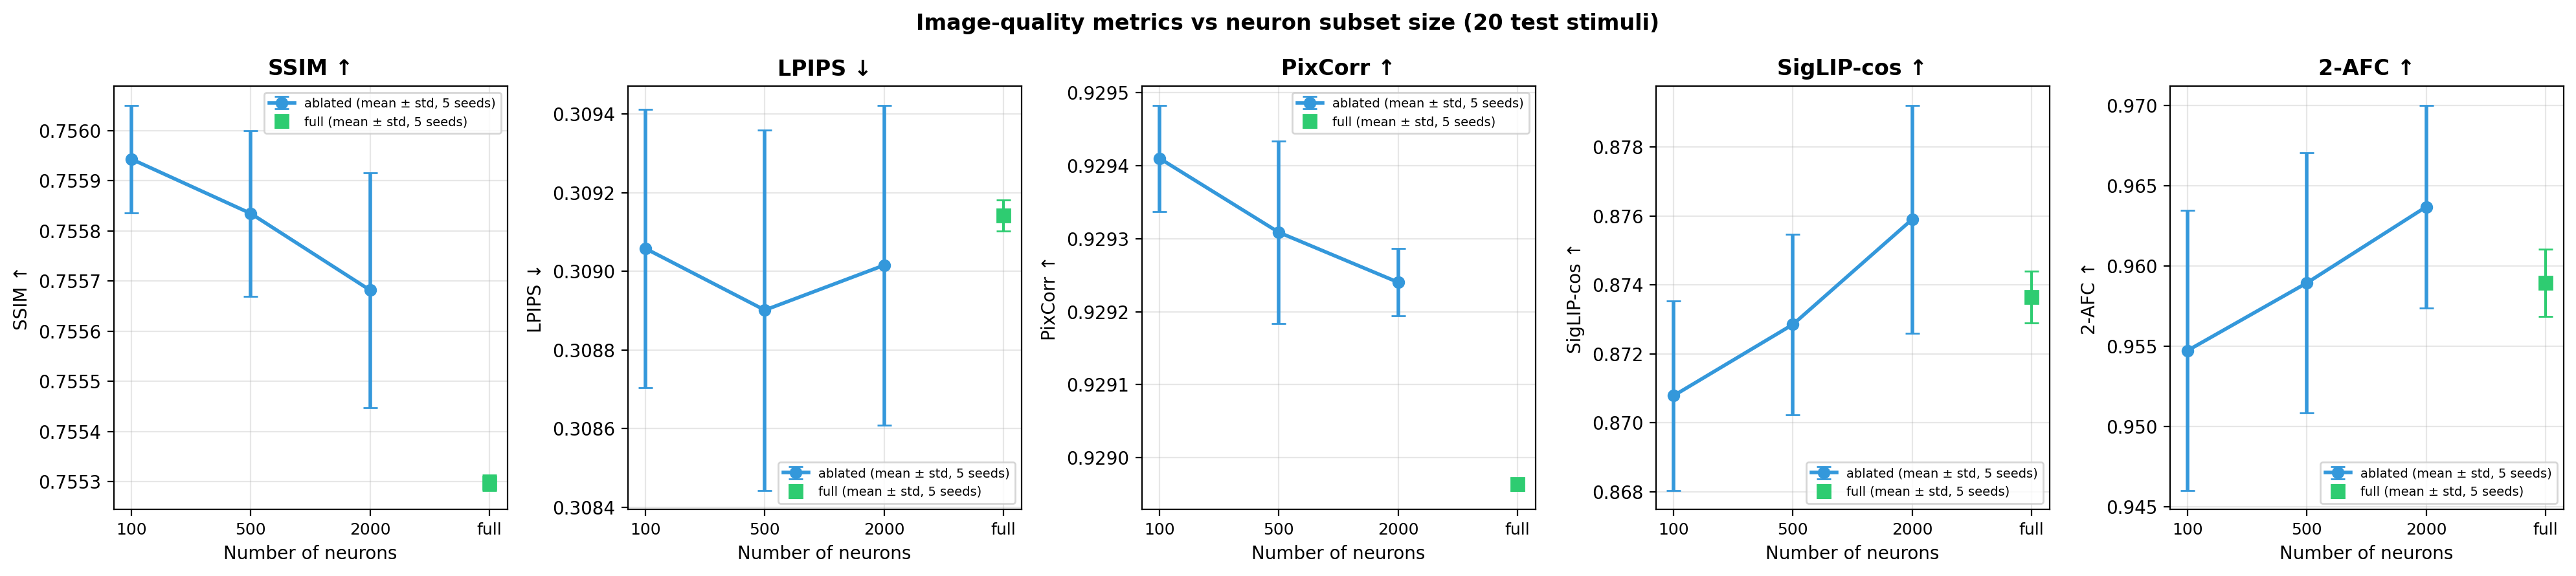

In [10]:
import matplotlib.pyplot as plt

METRIC_KEYS   = ['ssim', 'lpips', 'pixcorr', 'siglip_cos', 'afc_2']
METRIC_LABELS = ['SSIM ↑', 'LPIPS ↓', 'PixCorr ↑', 'SigLIP-cos ↑', '2-AFC ↑']

ALL_LEVELS = NN_VALS + [FULL_KEY]   # x-axis levels in order

def aggregate_level(nn_key, metric_key):
    """Mean ± std across 5 seeds for one level."""
    vals = [
        (all_metrics[(nn_key, s)][metric_key].mean()
         if isinstance(all_metrics[(nn_key, s)][metric_key], np.ndarray)
         else float(all_metrics[(nn_key, s)][metric_key]))
        for s in range(N_SEEDS)
    ]
    return np.mean(vals), np.std(vals)


fig, axes = plt.subplots(1, len(METRIC_KEYS), figsize=(20, 4.5))
color_ablate = '#3498db'
color_full   = '#2ecc71'

for ax, mk, ml in zip(axes, METRIC_KEYS, METRIC_LABELS):
    xs     = list(range(len(NN_VALS)))
    means  = [aggregate_level(nn, mk)[0] for nn in NN_VALS]
    stds   = [aggregate_level(nn, mk)[1] for nn in NN_VALS]
    full_m, full_s = aggregate_level(FULL_KEY, mk)

    ax.errorbar(xs, means, yerr=stds, fmt='o-', color=color_ablate,
                capsize=4, lw=2, label='ablated (mean ± std, 5 seeds)')
    ax.errorbar([len(NN_VALS)], [full_m], yerr=[full_s], fmt='s', color=color_full,
                capsize=4, markersize=7, label='full (mean ± std, 5 seeds)')

    ax.set_xticks(list(range(len(NN_VALS) + 1)))
    ax.set_xticklabels([str(nn) for nn in NN_VALS] + ['full'], fontsize=9)
    ax.set_xlabel('Number of neurons')
    ax.set_ylabel(ml)
    ax.set_title(ml, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Image-quality metrics vs neuron subset size ({N} test stimuli)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('outputs/ablation/image_metrics.pdf', bbox_inches='tight')
plt.show()

In [11]:
import pandas as pd

rows = {}
for nn in NN_VALS + [FULL_KEY]:
    row = {}
    for mk, ml in zip(METRIC_KEYS, METRIC_LABELS):
        m, s = aggregate_level(nn, mk)
        row[ml] = f'{m:.4f} ± {s:.4f}'
    rows[str(nn)] = row

df = pd.DataFrame(rows, index=METRIC_LABELS).T
df.index.name = 'Model'

def highlight_best(s):
    means = np.array([float(v.split(' ')[0]) for v in s])
    higher_better = '↓' not in s.name
    best = int(np.argmin(means) if not higher_better else np.argmax(means))
    return ['font-weight: bold; background-color: #d4edda' if i == best else '' for i in range(len(means))]

df.style.apply(highlight_best).set_caption(
    f'Mean ± std across 5 seeds, {N} test stimuli — full-image sequential neural pred')

,SSIM ↑,LPIPS ↓,PixCorr ↑,SigLIP-cos ↑,2-AFC ↑
Model,,,,,
100,0.7559 ± 0.0001,0.3091 ± 0.0004,0.9294 ± 0.0001,0.8708 ± 0.0027,0.9547 ± 0.0087
500,0.7558 ± 0.0002,0.3089 ± 0.0005,0.9293 ± 0.0001,0.8729 ± 0.0026,0.9589 ± 0.0081
2000,0.7557 ± 0.0002,0.3090 ± 0.0004,0.9292 ± 0.0000,0.8759 ± 0.0033,0.9637 ± 0.0063
full,0.7553 ± 0.0000,0.3091 ± 0.0000,0.9290 ± 0.0000,0.8736 ± 0.0008,0.9589 ± 0.0021


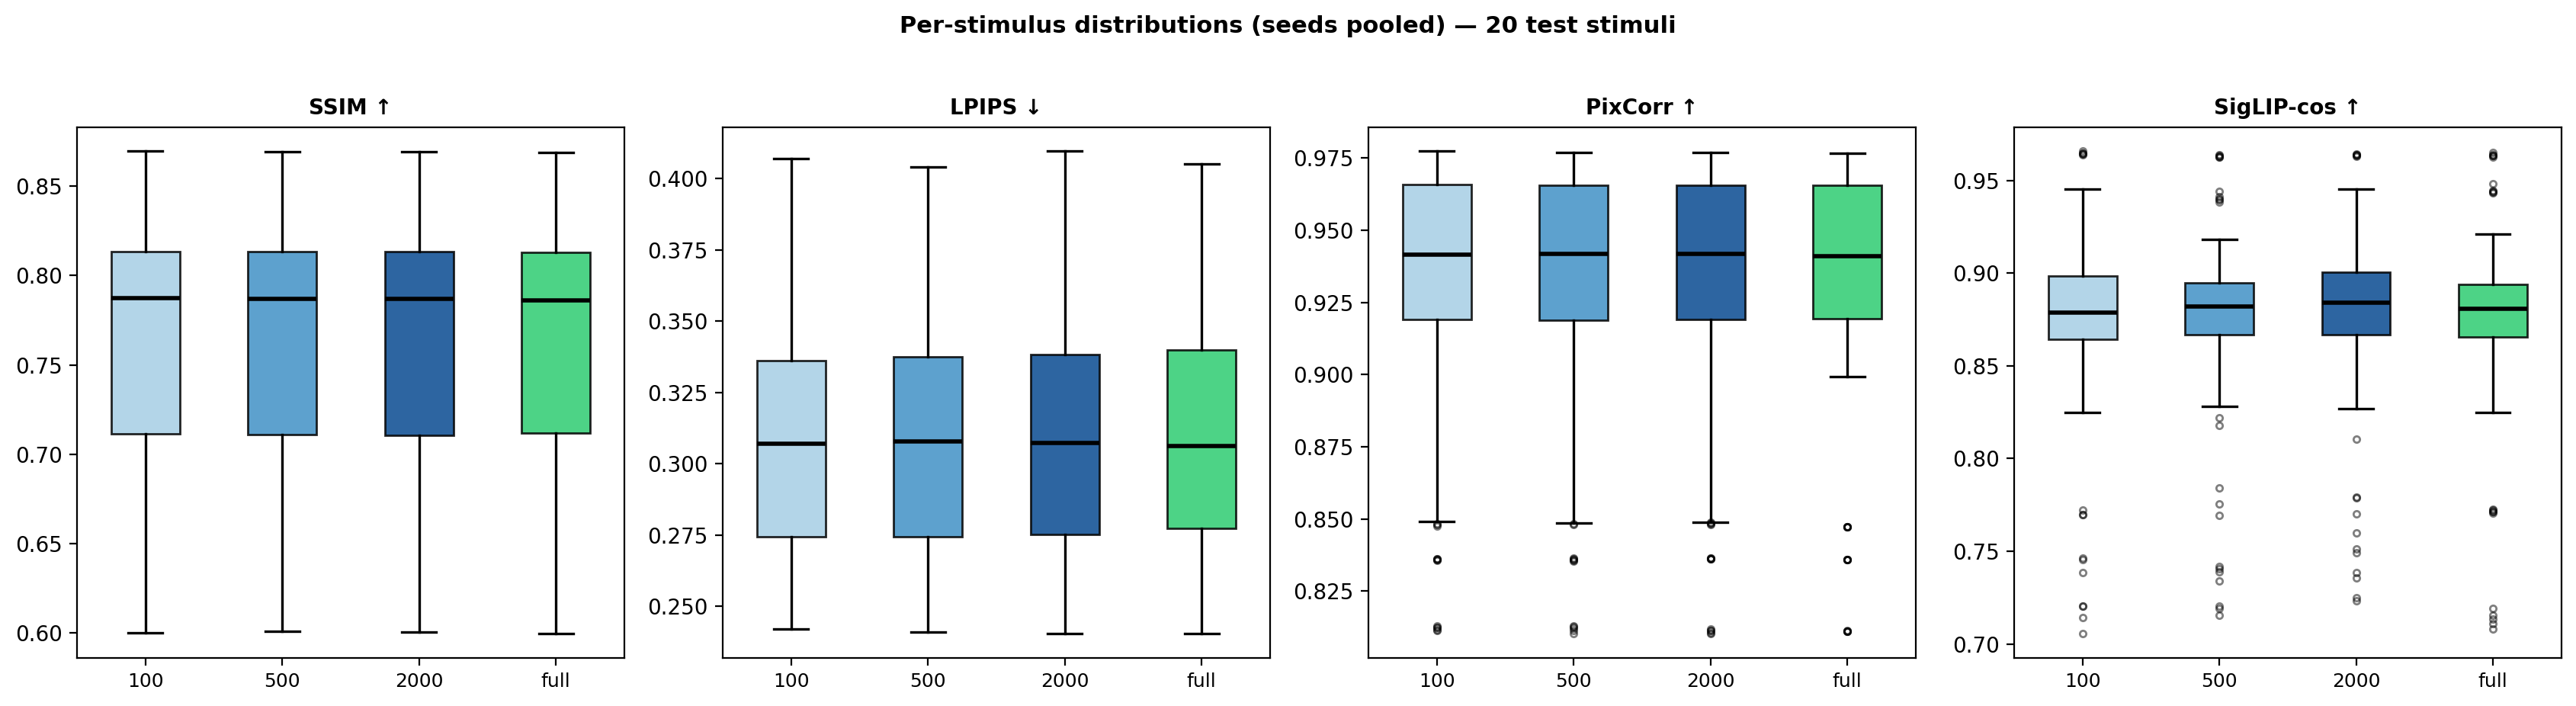

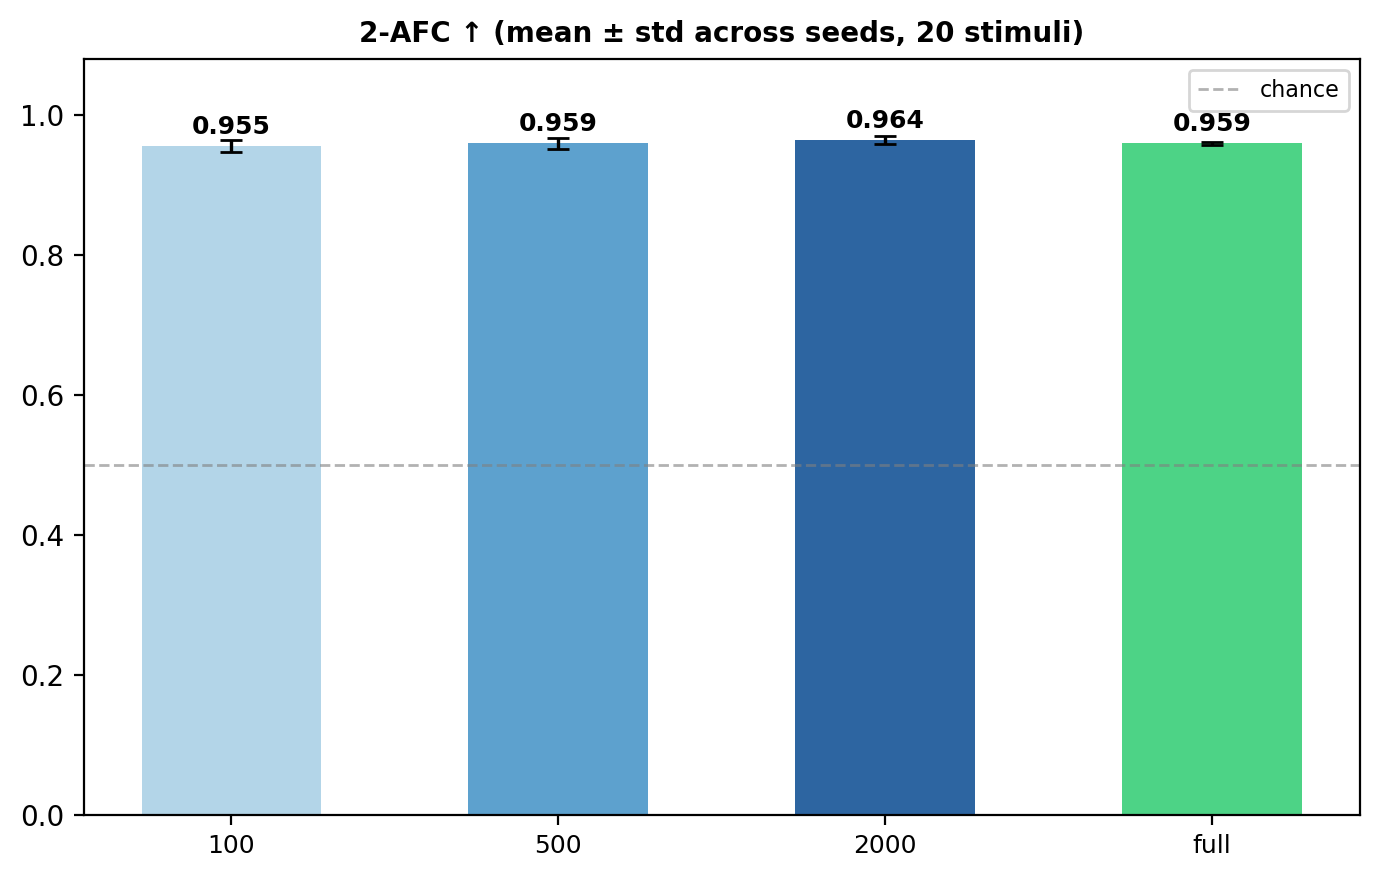

In [12]:
BOXPLOT_METRICS = [
    ('ssim',       'SSIM ↑'),
    ('lpips',      'LPIPS ↓'),
    ('pixcorr',    'PixCorr ↑'),
    ('siglip_cos', 'SigLIP-cos ↑'),
]

level_labels = [str(nn) for nn in NN_VALS] + ['full']
cmap = plt.cm.Blues
level_colors = [cmap(0.35 + 0.55 * i / (len(NN_VALS) - 1)) for i in range(len(NN_VALS))] + ['#2ecc71']

fig, axes = plt.subplots(1, len(BOXPLOT_METRICS), figsize=(17, 4.5))
for ax, (mk, ml) in zip(axes, BOXPLOT_METRICS):
    data = []
    for nn in NN_VALS:
        data.append(np.concatenate([all_metrics[(nn, s)][mk] for s in range(N_SEEDS)]))
    data.append(np.concatenate([all_metrics[(FULL_KEY, s)][mk] for s in range(N_SEEDS)]))

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
    for patch, color in zip(bp['boxes'], level_colors):
        patch.set_facecolor(color); patch.set_alpha(0.85)
    ax.set_xticks(range(1, len(level_labels) + 1))
    ax.set_xticklabels(level_labels, fontsize=9)
    ax.set_title(ml, fontsize=10, fontweight='bold')

fig.suptitle(f'Per-stimulus distributions (seeds pooled) — {N} test stimuli', fontsize=11, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

# 2-AFC bar
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
afc_vals = [aggregate_level(nn, 'afc_2')[0] for nn in NN_VALS + [FULL_KEY]]
afc_stds = [aggregate_level(nn, 'afc_2')[1] for nn in NN_VALS + [FULL_KEY]]

bars = ax2.bar(range(len(level_labels)), afc_vals, yerr=afc_stds,
               color=level_colors, alpha=0.85, width=0.55,
               capsize=4, error_kw=dict(lw=1.2))
ax2.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.6, label='chance')
for bar, v in zip(bars, afc_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(level_labels)))
ax2.set_xticklabels(level_labels, fontsize=9)
ax2.set_title(f'2-AFC ↑ (mean ± std across seeds, {N} stimuli)', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.08)
ax2.legend(fontsize=8)
fig2.tight_layout()
plt.show()